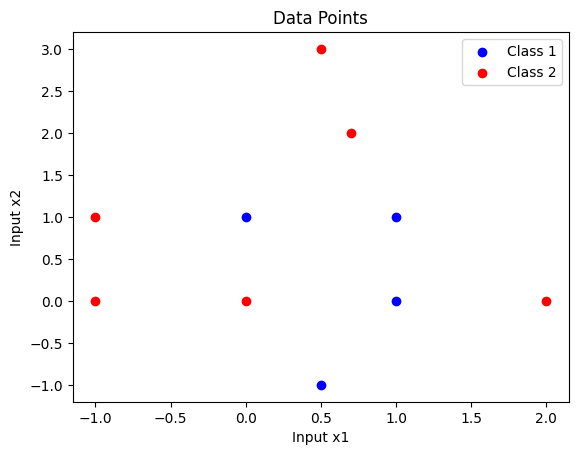

Training completed.


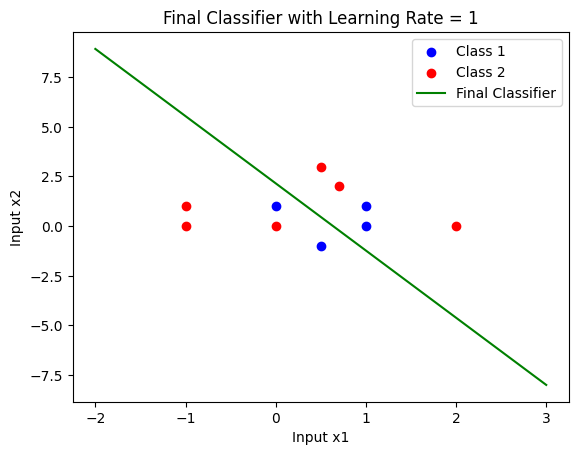

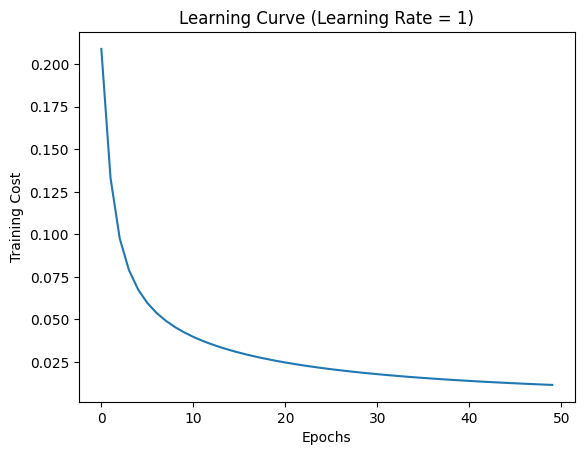

Training completed.


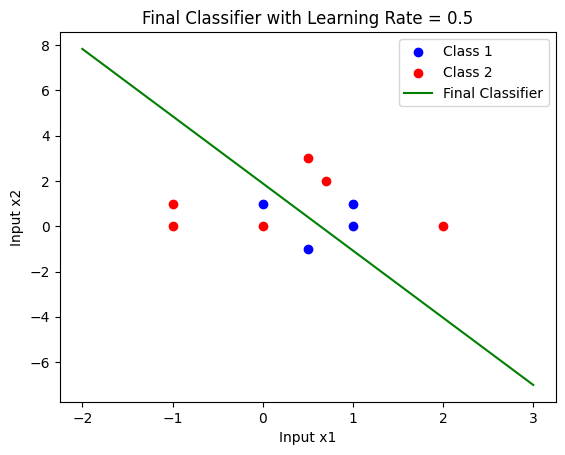

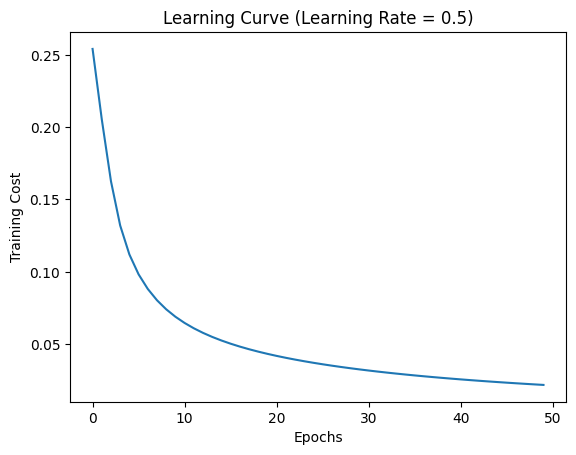

Training completed.


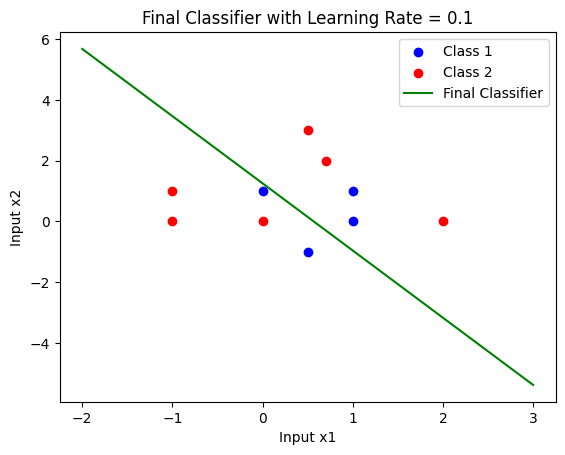

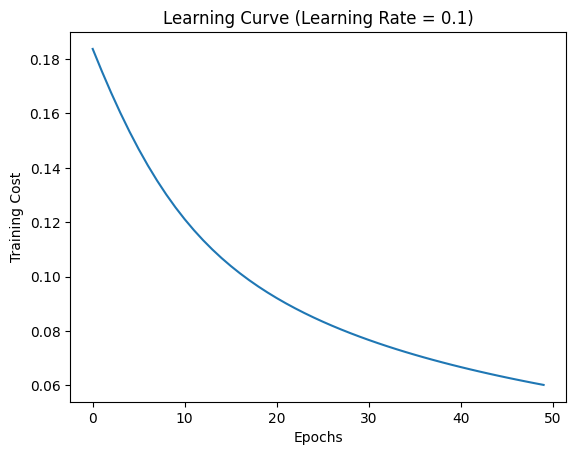

Training completed.


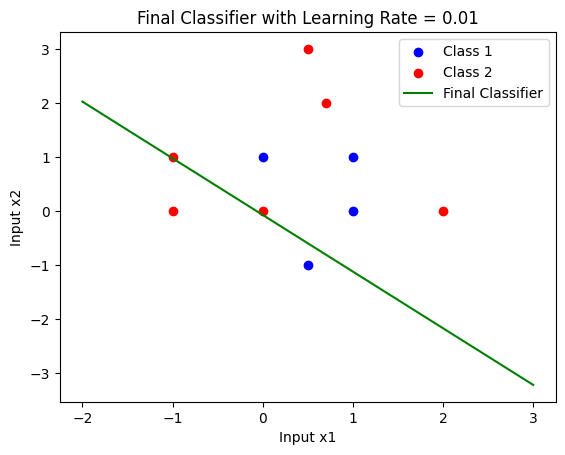

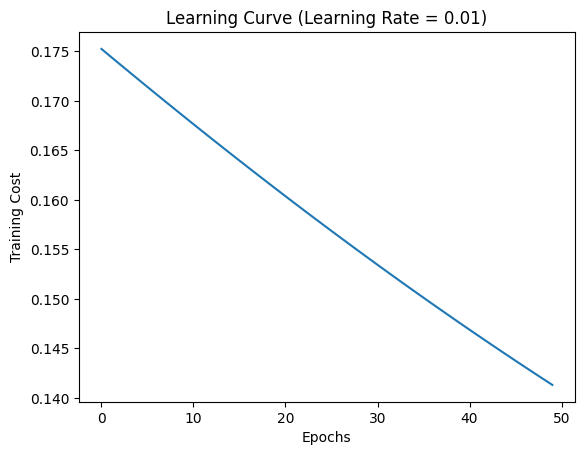

In [ ]:
# Noah Russell            3-9-24

# Import our databases
import numpy as np
import matplotlib.pyplot as plt

# Part a) i.
class NeuralNetwork:
    def __init__(self, learning_r):
        self.weights = np.random.rand(3, 1) # Initialize 3x1 vector rate randomly
        self.learning_rate = learning_r # Initialize learning rate to learning_r
        self.history = {'weights': [], 'cost': []} # History variable to save weights and cost after each epoch

# Part a) ii.
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x)) # Initialize sigmoid function as instructed

# Part a) iii.
    def forward_propagation(self, inputs):
        return self.sigmoid(np.dot(inputs, self.weights)) # Multiply  inputs by  neuron weights + uses sigmoid activation function

# Part a) iv.
    def train(self, inputs_train, labels_train, num_train_iterations):
        for epoch in range(num_train_iterations): # performs gradient descent learning rule for num_train_iterations times using inputs and labels

            # Forward propagation
            outputs = self.forward_propagation(inputs_train) # Generate output instructed in part a) iii.

            # Calculate the error
            error = labels_train - outputs

            # Update weights using gradient descent
            self.weights += self.learning_rate * np.dot(inputs_train.T, error * (outputs * (1 - outputs)))

            # Calculate and store the cost
            cost = np.mean(np.square(error))
            self.history['cost'].append(cost)
            self.history['weights'].append(self.weights)

        print("Training completed.") # Indicate we've finished one iteration

# Our given data points
# Part b) i.
inputs = np.array([[1, 1], [1, 0], [0, 1], [0.5, -1], [0.5, 3], [0.7, 2], [-1, 0], [-1, 1], [2, 0], [0, 0]]) # Given datapoints
labels = np.array([[1], [1], [0], [0], [1], [1], [0], [0], [1], [0]]) # Desired output

# Plotting data points
# Part b) ii.
plt.scatter(inputs[:4, 0], inputs[:4, 1], c='blue', label='Class 1')
plt.scatter(inputs[4:, 0], inputs[4:, 1], c='red', label='Class 2')
plt.xlabel('Input x1')
plt.ylabel('Input x2')
plt.legend()
plt.title('Data Points')
plt.show()

# Adding bias to inputs
# Part b) iii.
inputs_with_bias = np.c_[inputs, np.ones((inputs.shape[0], 1))]

# Training with learning rate of 1
# Part b) iv.
network = NeuralNetwork(1)
network.train(inputs_with_bias, labels, 50)

# Setting up final classifier line (for lr = 1)
# Part c)
x_vals = np.linspace(-2, 3, 100) # setting up suitable x-axis for our lr = 1
y_vals = (-network.weights[0] * x_vals - network.weights[2]) / network.weights[1] # y-axis span to suit our lr
plt.scatter(inputs[:4, 0], inputs[:4, 1], c='blue', label='Class 1') # import our data points for class 1
plt.scatter(inputs[4:, 0], inputs[4:, 1], c='red', label='Class 2') # import our datapoints for class 2
plt.plot(x_vals, y_vals, c='green', label='Final Classifier')
plt.xlabel('Input x1')
plt.ylabel('Input x2')
plt.legend()
plt.title('Final Classifier with Learning Rate = 1')
plt.show()

# Setting up learning curve (for lr = 1)
# Part d)
plt.plot(range(50), network.history['cost'])
plt.xlabel('Epochs')
plt.ylabel('Training Cost')
plt.title('Learning Curve (Learning Rate = 1)')
plt.show()

# Repeating the process with different learning rates (given)
learning_rates = [0.5, 0.1, 0.01]

# Part e) Repeating steps for all other lr's
for lr in learning_rates:
    # Creating the network with one neuron and training it
    network = NeuralNetwork(lr)
    network.train(inputs_with_bias, labels, 50)

    # Setting up final classifier line (for all learning_rates)
    x_vals = np.linspace(-2, 3, 100) # setting up suitable x-axis for our different lr's
    y_vals = (-network.weights[0] * x_vals - network.weights[2]) / network.weights[1] # situational y-values bc our lr's are drastically different
    plt.scatter(inputs[:4, 0], inputs[:4, 1], c='blue', label='Class 1') # import our data points for class 1
    plt.scatter(inputs[4:, 0], inputs[4:, 1], c='red', label='Class 2') # import our datapoints for class 2
    plt.plot(x_vals, y_vals, c='green', label='Final Classifier')
    plt.xlabel('Input x1')
    plt.ylabel('Input x2')
    plt.legend()
    plt.title(f'Final Classifier with Learning Rate = {lr}')
    plt.show()

    # Setting up learning curve (for all learning_rates)
    plt.plot(range(50), network.history['cost'])
    plt.xlabel('Epochs')
    plt.ylabel('Training Cost')
    plt.title(f'Learning Curve (Learning Rate = {lr})')
    plt.show()

# Part f) What behavior do you observe from the learning curves with the different learning rates? Explain your observations. Which learning rate is more suitable? Explain
# We can clearly see that learning curves for higher learning rates (like 0.5 and 0.1) converge faster compared to our lower learning rates (0.01).
# We can also see that learning rates curves for higher learning rates are more fluctuant and may not stabilize
# In conclusion, since 0.1 converges quickly and appears to be the most stable, it is our most suitable learning rate.
